Connecting to: USB0::0x0957::0x1307::MY48000262::0::INSTR
Running bench test (immediate trigger)...
Pulse captured! Fetching calibrated voltage data...
Success! Saved 4 channels to pulse_shot_20260925_180811.npz


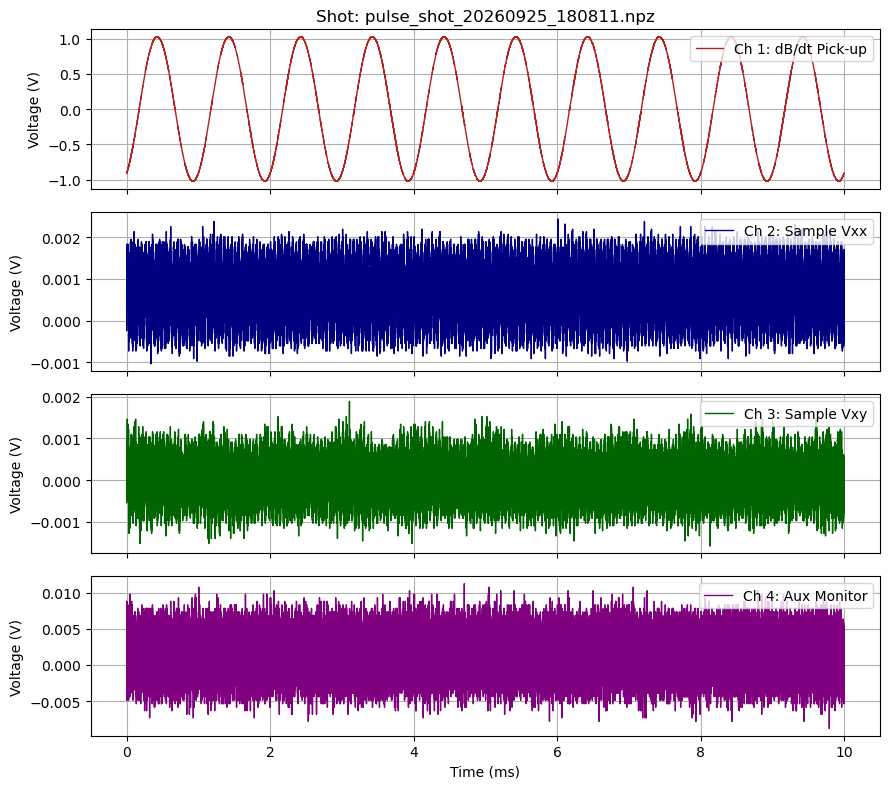

In [12]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pyvisa

VISA_ADDRESS = "USB0::0x0957::0x1307::MY48000262::0::INSTR"

SAMPLE_RATE = 20_000_000
TOTAL_POINTS = 200_000
PRE_TRIG_PTS = 20_000

CHANNELS = {
    1: {"name": "dB/dt Pick-up", "range": 2.0, "color": "firebrick"},
    2: {"name": "Sample Vxx", "range": 2.0, "color": "navy"},
    3: {"name": "Sample Vxy", "range": 2.0, "color": "darkgreen"},
    4: {"name": "Aux Monitor", "range": 10.0, "color": "purple"},
}

TRIGGER_MODE = "IMM"  # "EXT" for magnet shots, "IMM" for bench testing
TIMEOUT_MS = 60_000


def run_experiment():
    rm = pyvisa.ResourceManager()
    print(f"Connecting to: {VISA_ADDRESS}")
    dig = rm.open_resource(VISA_ADDRESS)
    dig.timeout = TIMEOUT_MS

    dig.write("*RST")
    dig.write("*CLS")

    dig.write(f":CONF:ACQ:SRAT {SAMPLE_RATE}")
    dig.write(f":CONF:ACQ:SCO {TOTAL_POINTS}")
    if PRE_TRIG_PTS > 0:
        dig.write(f":CONF:ACQ:SPR {PRE_TRIG_PTS}")

    for ch, cfg in CHANNELS.items():
        dig.write(f":CONF:CHAN:ATTR (@{ch}), {cfg['range']}, DC, LP_20_MHZ")

    dig.write(":FORM:DATA:REAL REAL,64")
    dig.write(":FORM:BORD NORM")

    dig.write(":CONF:ARM:SOUR IMM")
    if TRIGGER_MODE == "EXT":
        dig.write(":CONF:TRIG:SOUR EXT")
        dig.write(":CONF:EXT:INP POS")
        print("\nArmed. Waiting on rear EXT TRIG BNC...")
    else:
        dig.write(":CONF:TRIG:SOUR IMM")
        print("Running bench test (immediate trigger)...")

    dig.write(":INIT")
    dig.query("*OPC?")
    print("Pulse captured! Fetching calibrated voltage data...")

    waveforms = {}
    for ch in CHANNELS:
        waveforms[f"v_ch{ch}"] = dig.query_binary_values(
            f":FETC:WAV:VOLT? (@{ch})",
            datatype="d",
            is_big_endian=True,
            container=np.array,
        )

    dig.close()

    time_shift = PRE_TRIG_PTS if TRIGGER_MODE == "EXT" else 0
    time_ms = ((np.arange(TOTAL_POINTS) - time_shift) / SAMPLE_RATE) * 1e3
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    shot_filename = f"pulse_shot_{timestamp}.npz"

    np.savez(
        shot_filename,
        time_ms=time_ms,
        sample_rate=SAMPLE_RATE,
        pre_trig_pts=time_shift,
        **waveforms,
    )
    print(f"Success! Saved 4 channels to {shot_filename}")

    fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
    for idx, (ch, cfg) in enumerate(CHANNELS.items()):
        ax = axes[idx]
        ax.plot(
            time_ms,
            waveforms[f"v_ch{ch}"],
            color=cfg["color"],
            lw=1.0,
            label=f"Ch {ch}: {cfg['name']}",
        )
        if TRIGGER_MODE == "EXT":
            ax.axvline(
                0, color="black", linestyle="--", alpha=0.7, label="Trigger"
            )
        ax.set_ylabel("Voltage (V)")
        ax.grid(True)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Time (ms)")
    axes[0].set_title(f"Shot: {shot_filename}")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    run_experiment()